# Reto 04 - Autoencoders

## Detección de anomalías en series de tiempo con autoencoders

> **Fuente del problema:** [Numenta Anomaly Benchmark (NAB)](https://www.kaggle.com/datasets/boltzmannbrain/nab)
> publicado en **Kaggle**, réplica del [repositorio original de Numenta](https://github.com/numenta/NAB), pensado para evaluar
> algoritmos de detección de anomalías en flujos de datos temporales (*streaming*).

### El problema

NAB es una colección de series de tiempo, tanto reales como artificiales, etiquetadas con la ubicación de sus anomalías, y diseñada
específicamente para evaluar algoritmos de detección de anomalías en condiciones cercanas a las de producción (datos que llegan de
forma continua, sin poder reentrenar el modelo con el conjunto completo de antemano). Dentro de esta colección, las series
**artificiales** (`artificialNoAnomaly/` y `artificialWithAnomaly/`) son señales sintéticas con un patrón periódico claro (una onda
con ruido leve) a las que se les inyectan anomalías controladas, lo que las vuelve ideales para un primer acercamiento a la técnica
sin la complejidad adicional de una serie real.

Un **autoencoder** aprende a reconstruir su propia entrada comprimiéndola a través de un cuello de botella. Si se entrena
únicamente con datos "normales", la red se especializa en reconstruir ese patrón y falla al reconstruir observaciones que se
desvían de él; el **error de reconstrucción** se convierte entonces en una señal de anomalía: valores altos indican secuencias que
el modelo no reconoce como parte del comportamiento habitual de la serie.

### Objetivo

1. Entrenar un **autoencoder** (rnn) sobre ventanas de la serie `art_daily_small_noise.csv`, que no contiene
   anomalías, para que aprenda a reconstruir el comportamiento normal de la serie.
2. Definir un **umbral de errorn** a partir del propio conjunto de entrenamiento.
3. Evaluar el modelo sobre `art_daily_jumpsup.csv`, una serie con el mismo patrón base pero que presenta un salto anómalo sostenido,
   y usar el umbral de error para **localizar la anomalía** en el tiempo.
4. Visualizar la serie original, el error de reconstrucción y los puntos marcados como anómalos para validar el resultado.

### Estructura de los datos

Usaremos únicamente dos archivos de la colección de series artificiales, cada uno con una columna `timestamp` y una columna
`value` muestreadas cada 5 minutos:

| Archivo | Carpeta en NAB | Uso | Contenido |
|---|---|---|---|
| `art_daily_small_noise.csv` | `artificialNoAnomaly/` | Entrenamiento | Serie diaria periódica con ruido leve, sin anomalías |
| `art_daily_jumpsup.csv` | `artificialWithAnomaly/` | Prueba | Misma serie base, con un salto anómalo sostenido inyectado |

La simplicidad de este conjunto de datos (una sola variable, un patrón periódico estable y una anomalía bien delimitada) permite
demostrar de forma clara el flujo completo de detección de anomalías con autoencoders, antes de enfrentarlo a series reales más
ruidosas.


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")


import mlflow
import keras
import keras_hub
import pathlib
import logging
import warnings


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline

from numpy.lib.stride_tricks import sliding_window_view

tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

warnings.filterwarnings("ignore", category=UserWarning)

AUTOTUNE = tf.data.AUTOTUNE

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("reto-04-autoencoders")
mlflow.tensorflow.autolog(
    log_models=True,
    log_input_examples=True,
    log_model_signatures=True,
    log_every_n_steps=10,
    log_every_epoch=False,
)

print(
    "Keras:",
    keras.__version__,
    "| backend:",
    keras.backend.backend(),
    "| GPUs:",
    tf.config.list_physical_devices("GPU"),
)

Keras: 3.15.1 | backend: tensorflow | GPUs: []


Columns: Index(['timestamp', 'value'], dtype='str')
Shape: (4032, 2) | Delta: 0 days 00:05:00
Max Date 2014-04-14 23:55:00 | Min Date 2014-04-01 00:00:00


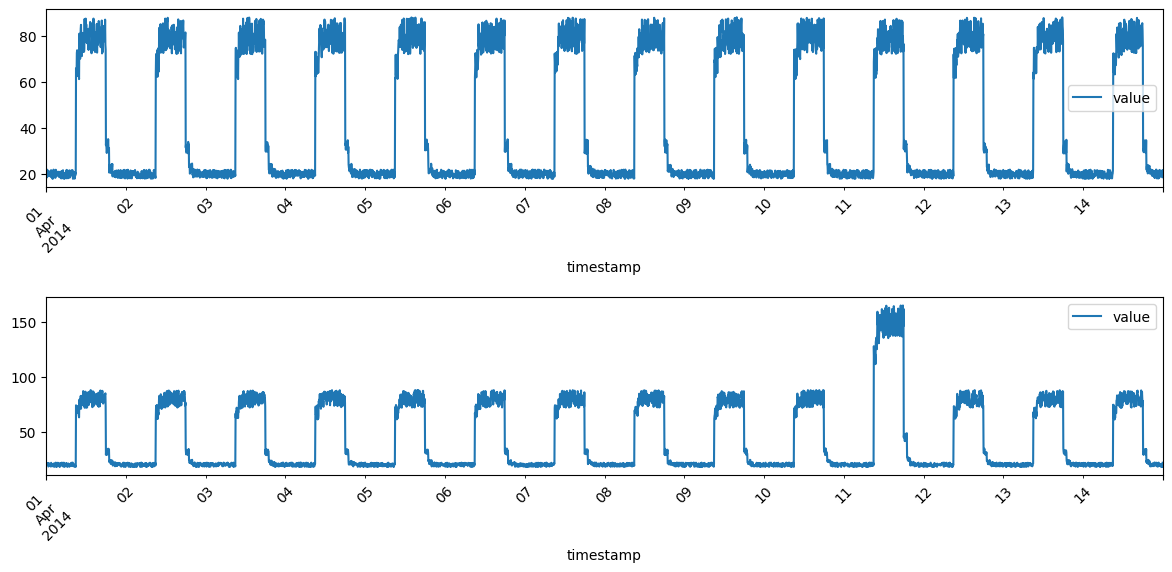

In [2]:
main_df = pd.read_csv(
    "../data/numenta-anomaly-benchmark/artificialNoAnomaly/artificialNoAnomaly/art_daily_small_noise.csv",
)

anomaly_df = pd.read_csv(
    "../data/numenta-anomaly-benchmark/artificialWithAnomaly/artificialWithAnomaly/art_daily_jumpsup.csv"
)

print("Columns:", main_df.columns)

main_df["timestamp"] = pd.to_datetime(main_df["timestamp"])
anomaly_df["timestamp"] = pd.to_datetime(anomaly_df["timestamp"])

delta = pd.to_datetime(main_df["timestamp"][1]) - pd.to_datetime(
    main_df["timestamp"][0]
)

print("Shape:", main_df.shape, "| Delta:", delta)

mint, maxt = main_df["timestamp"].min(), main_df["timestamp"].max()

print("Max Date", maxt, "| Min Date", mint)

fig, ax = plt.subplots(2, 1, figsize=(12, 6))

main_df.plot(x=main_df.columns[0], rot=45, ax=ax[0])
anomaly_df.plot(x=anomaly_df.columns[0], rot=45, ax=ax[1])
plt.tight_layout(pad=1.7)

In [3]:
WINDOW = 100
HORIZON = 20
SIZE = 3800

Shape: (3800, 100, 2) | Shape (3800, 20, 2)


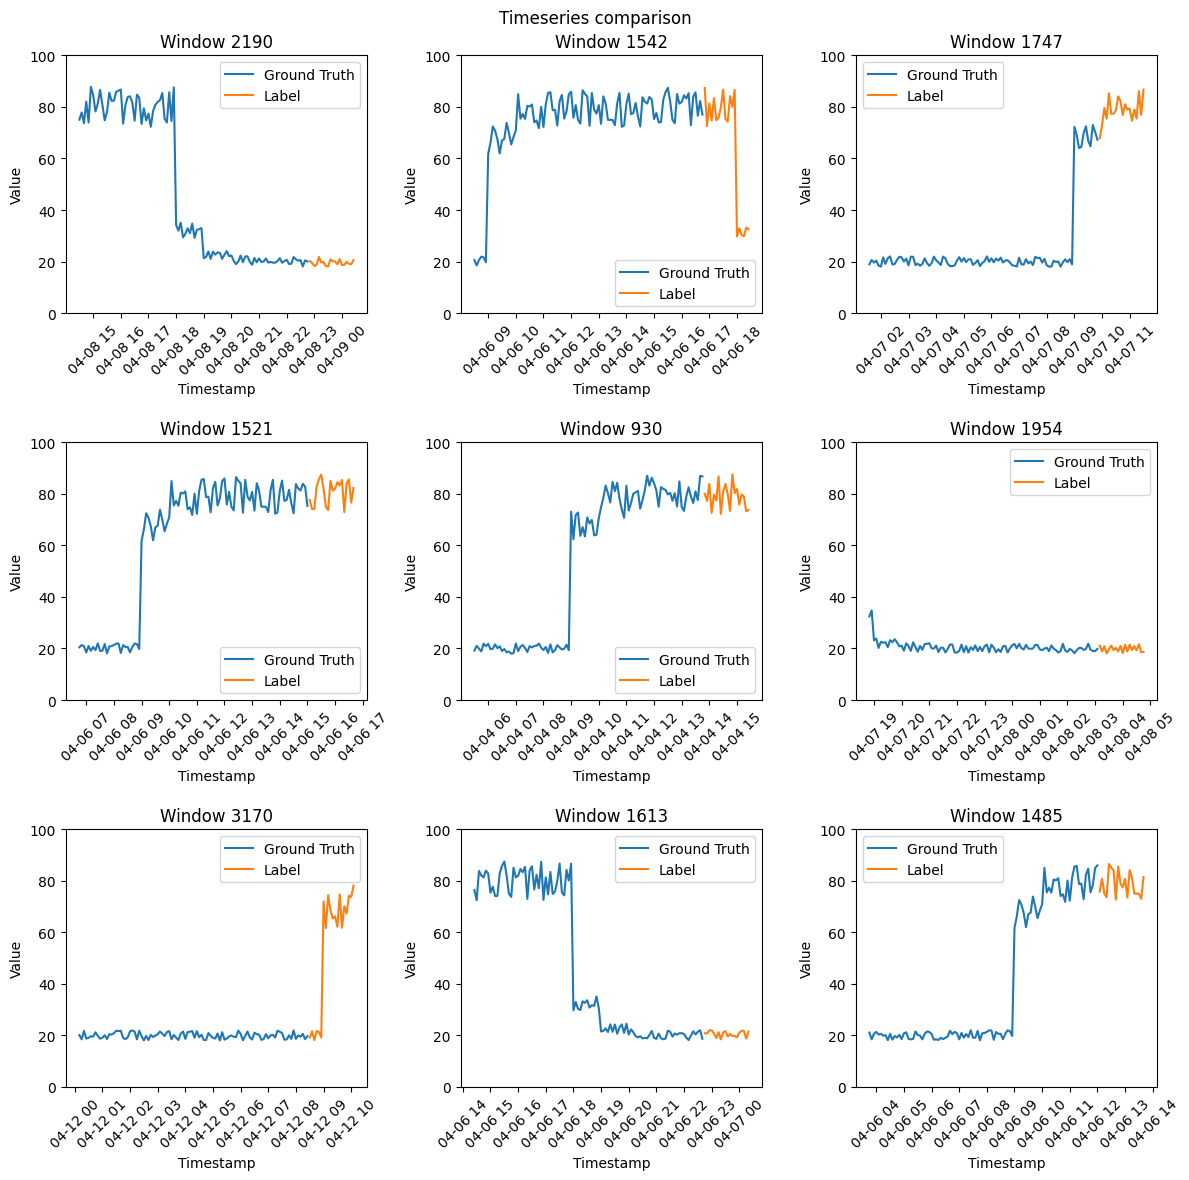

In [4]:
def make_sliding_window(
    dataframe,
    window: int = 10,
    horizon: int = 5,
    size: int = 100,
):
    X = sliding_window_view(
        dataframe, window_shape=(window, dataframe.shape[1])
    ).squeeze()

    y = sliding_window_view(
        dataframe, window_shape=(window + horizon, dataframe.shape[1])
    ).squeeze()

    # truncate the values from the window
    y = y[:, window:]

    return X[:size], y[:size]


X, y = make_sliding_window(main_df, window=WINDOW, horizon=HORIZON, size=SIZE)

print("Shape:", X.shape, "| Shape", y.shape)


def plot_timeseries(X, y, nrows: int = 2, ncols: int = 2):
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle("Timeseries comparison")

    axs = axs.ravel()

    for ax in axs:
        i = np.random.randint(0, X.shape[0])
        ax.set_title(f"Window {i}")
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", labelrotation=45)
        ax.plot(
            pd.date_range(X[i, :, 0][0], X[i, :, 0][-1], freq="5min"),
            X[i, :, 1],
            label="Ground Truth",
        )
        ax.plot(
            pd.date_range(y[i, :, 0][0], y[i, :, 0][-1], freq="5min"),
            y[i, :, 1],
            label="Label",
        )
        ax.legend()
        ax.set_ylabel("Value")
        ax.set_xlabel("Timestamp")

    plt.tight_layout(h_pad=1.7)


plot_timeseries(X, y, nrows=3, ncols=3)

In [5]:
def cyclic_transformer(period):
    def forward(x):
        x = np.asarray(x, dtype=float)
        angle = x / period * 2 * np.pi
        return np.hstack([np.sin(angle), np.cos(angle)])

    def inverse(x):
        x = np.asarray(x, dtype=float)
        n = x.shape[1] // 2
        angle = np.arctan2(x[:, :n], x[:, n:])
        return (angle / (2 * np.pi) * period) % period

    def names(input_features):
        return [f"{f}_sin" for f in input_features] + [
            f"{f}_cos" for f in input_features
        ]

    return FunctionTransformer(forward, inverse, feature_names_out=names)


def dt_part(attr):
    return FunctionTransformer(
        lambda x: getattr(pd.to_datetime(x["timestamp"]).dt, attr).to_frame(),
        inverse_func=lambda x: x,
        check_inverse=False,
        feature_names_out=lambda self, names: [attr],
    )

In [6]:
transform_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ("extract_day", dt_part("day"), ["timestamp"]),
            ("extract_weekday", dt_part("weekday"), ["timestamp"]),
            ("extract_hour", dt_part("hour"), ["timestamp"]),
            ("extract_min", dt_part("minute"), ["timestamp"]),
        ],
        remainder="passthrough",
    ),
    ColumnTransformer(
        transformers=[
            ("day", cyclic_transformer(31), [0]),
            ("weekday", cyclic_transformer(7), [1]),
            ("hour", cyclic_transformer(24), [2]),
            ("minute", cyclic_transformer(60), [3]),
        ],
        remainder=StandardScaler(),
    ),
)

In [7]:
X_train, X_val = train_test_split(
    main_df,
    test_size=0.2,
    shuffle=False,
)

print("Shape:", X_train.shape, "| Shape:", X_val.shape)

Shape: (3225, 2) | Shape: (807, 2)


In [8]:
transform_pipeline.fit(X_train)

X_train_processed = transform_pipeline.transform(X_train)
X_val_processed = transform_pipeline.transform(X_val)
X_test_processed = transform_pipeline.transform(anomaly_df)

X_train_windows = sliding_window_view(
    X_train_processed,
    window_shape=(WINDOW, X_train_processed.shape[1]),
).squeeze()

X_val_windows = sliding_window_view(
    X_val_processed,
    window_shape=(WINDOW, X_val_processed.shape[1]),
).squeeze()

X_test_windows = sliding_window_view(
    X_test_processed,
    window_shape=(WINDOW, X_test_processed.shape[1]),
).squeeze()

X_train_windows.shape, X_val_windows.shape, X_test_windows.shape

((3126, 100, 9), (708, 100, 9), (3933, 100, 9))

## Build Model

In [9]:
def build_model(
    timesteps, features, latent_space=128, activation="tanh", init="glorot_uniform"
):
    inputs = keras.Input(shape=(timesteps, features), name="inputs")

    # Encoder
    x = keras.layers.LSTM(
        latent_space * 2,
        activation=activation,
        return_sequences=True,
        kernel_initializer=init,
        name="lstm_enc_2",
    )(inputs)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.LSTM(
        latent_space,
        activation=activation,
        return_sequences=False,
        kernel_initializer=init,
        name="lstm_enc_1",
    )(x)

    # Decoder
    d = keras.layers.RepeatVector(timesteps)(x)
    d = keras.layers.LSTM(
        latent_space,
        activation=activation,
        return_sequences=True,
        kernel_initializer=init,
        name="lstm_dec_1",
    )(d)
    d = keras.layers.Dropout(0.2)(d)
    d = keras.layers.LSTM(
        latent_space * 2,
        activation=activation,
        return_sequences=True,
        kernel_initializer=init,
        name="lstm_dec_2",
    )(d)

    # Output
    outs = keras.layers.TimeDistributed(
        keras.layers.Dense(
            features,
            kernel_initializer=init,
        ),
        name="timedistributed_dense",
    )(d)

    model = keras.Model(
        inputs,
        outs,
        name="autoencoder_timeseries",
    )

    extractor = keras.Model(
        inputs=model.inputs,
        outputs=x,
        name="extractor_timeseries",
    )

    return model, extractor


model, extractor = build_model(WINDOW, X_train_windows.shape[-1])
model.summary(), extractor.summary()

Model: "autoencoder_timeseries"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 100, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_2 (LSTM)               │ (None, 100, 256)       │       272,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_1 (LSTM)               │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_1 (LSTM)               │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_2 (LSTM)               │ (None, 100, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ timedistributed_dense           │ (None, 100, 9)         │         2,313 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 997,641 (3.81 MB)

 Trainable params: 997,641 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 100, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_2 (LSTM)               │ (None, 100, 256)       │       272,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_enc_1 (LSTM)               │ (None, 128)            │       197,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,504 (1.79 MB)

 Trainable params: 469,504 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

(None, None)

In [10]:
EPOCHS = 50
WARMUP_EPOCHS = 3

# Calculamos la cantidad de total de steps y ubicamos un 10% para warmup del lr
steps_per_epoch = int(np.ceil(X_train_windows.shape[0] / 32))
total_steps = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    warmup_target=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps - warmup_steps,
    alpha=0.01,
)

print(
    f"pasos/época: {steps_per_epoch} | warmup: {warmup_steps} | "
    f"decay: {total_steps - warmup_steps} | total: {total_steps}"
)

RUTA_MODELO = pathlib.Path(f"../models/reto-04-{model.name}.keras")
RUTA_MODELO.parent.mkdir(parents=True, exist_ok=True)


optim_fn = keras.optimizers.Adam(learning_rate=scheduler)  # type: ignore

stop_cb = keras.callbacks.EarlyStopping(
    patience=5,
    mode="min",
)
best_cb = keras.callbacks.ModelCheckpoint(
    filepath=RUTA_MODELO,
    save_best_only=True,
    mode="min",
)


class LearningRateLogger(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs={}):
        optim = self.model.optimizer  # type: ignore
        lr = optim.learning_rate
        if isinstance(lr, keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(optim.iterations)
        logs["learning_rate"] = float(keras.ops.convert_to_numpy(lr))  # type: ignore


lr_cb = LearningRateLogger()


model.compile(
    optimizer=optim_fn,
    loss=keras.losses.MeanSquaredError(),
)

with mlflow.start_run():
    history = model.fit(
        X_train_windows,
        X_train_windows,
        epochs=EPOCHS,
        shuffle=True,
        batch_size=32,
        callbacks=[best_cb, lr_cb, stop_cb],
        validation_data=(X_val_windows, X_val_windows),
    )

print("Modelo guardado en:", RUTA_MODELO.resolve())

pasos/época: 98 | warmup: 294 | decay: 4606 | total: 4900


Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.3935

98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - loss: 0.3935 - val_loss: 0.2754 - learning_rate: 1.0667e-04
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1811

98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.1811 - val_loss: 0.1967 - learning_rate: 2.0333e-04
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.1475

98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.1475 - val_loss: 0.1885 - learning_rate: 3.0000e-04
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.1388

98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.1388 - val_loss: 0.1835 - learning_rate: 2.9967e-04
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.1328

98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - loss: 0.1328 - val_loss: 0.1817 - learning_rate: 2.9868e-04
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.1297 - val_loss: 0.1876 - learning_rate: 2.9702e-04
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.1283 - val_loss: 0.1863 - learning_rate: 2.9472e-04
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.1263 - val_loss: 0.1940 - learning_rate: 2.9178e-04
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - loss: 0.1261 - val_loss: 0.1896 - learning_rate: 2.8822e-04
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - loss: 0.1238 - val_loss: 0.1935 - learning_rate: 2.8404e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step


2026/09/16 16:23:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 16:23:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
🏃 View run painted-panda-895 at: http://127.0.0.1:5000/#/experiments/1/runs/aa938a50cf5f4ed3b030a6eb6225b663
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Modelo guardado en: /Users/jmanuelc87/Documents/Projects Single Repository/bourbaki-track-ciencia-datos/03-deep-learning/models/reto-04-autoencoder_timeseries.keras


In [11]:
LR_KEYS = ("learning_rate", "lr")


def plot_history(
    history,
    metrics=None,
    cols: int = 2,
    figsize_scale: float = 4.5,
    skip_first: int = 0,
    log_loss: bool = False,
):
    """Grafica entrenamiento vs. validación por época y devuelve el historial como DataFrame."""
    registro = history.history if hasattr(history, "history") else dict(history)
    df = pd.DataFrame(registro)
    df.index = np.arange(1, len(df) + 1)
    df.index.name = "epoch"

    if metrics is None:
        metrics = [k for k in df.columns if not k.startswith("val_")]
        orden = {k: i for i, k in enumerate(metrics)}
        metrics.sort(
            key=lambda k: (
                2 if k in LR_KEYS else (0 if "loss" in k else 1),
                orden[k],
            )
        )

    metrics = [k for k in metrics if k in df.columns]
    if not metrics:
        raise ValueError("No hay métricas que graficar en el historial")

    epocas = df.index[skip_first:]
    cols = min(cols, len(metrics))
    rows = int(np.ceil(len(metrics) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_scale * 1.4, rows * figsize_scale),
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, metric in zip(axes, metrics):
        if metric in LR_KEYS:
            lr = df[metric].to_numpy()[skip_first:]
            ax.plot(epocas, lr, color="#2E7D32", marker="o", ms=3)
            ax.set_yscale("log")
            ax.set_title(
                f"{metric} — de {lr[0]:.2e} a {lr[-1]:.2e} (máx {lr.max():.2e})",
                fontsize=10,
            )
            ax.set_xlabel("Época")
            ax.set_ylabel("learning rate")
            continue

        es_perdida = "loss" in metric or "mean_absolute_error" in metric
        serie = df[metric].to_numpy()[skip_first:]
        ax.plot(epocas, serie, label="entrenamiento", color="#4A6FA5", marker="o", ms=3)

        val_key = f"val_{metric}"
        if val_key in df.columns:
            val = df[val_key].to_numpy()[skip_first:]
            ax.plot(epocas, val, label="validación", color="#B3261E", marker="o", ms=3)

            mejor = int(np.argmin(val) if es_perdida else np.argmax(val))
            ax.axvline(epocas[mejor], color="#999999", ls="--", lw=1)
            ax.scatter(epocas[mejor], val[mejor], color="#B3261E", zorder=3)
            ax.set_title(
                f"{metric} — mejor validación: {val[mejor]:.4f} (época {epocas[mejor]})",
                fontsize=10,
            )
        else:
            ax.set_title(metric, fontsize=10)

        if es_perdida and log_loss:
            ax.set_yscale("log")

        ax.set_xlabel("Época")
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)

    for ax in axes[len(metrics) :]:
        ax.axis("off")

    fig.suptitle(f"Historial de entrenamiento — {len(df)} épocas")
    plt.show()

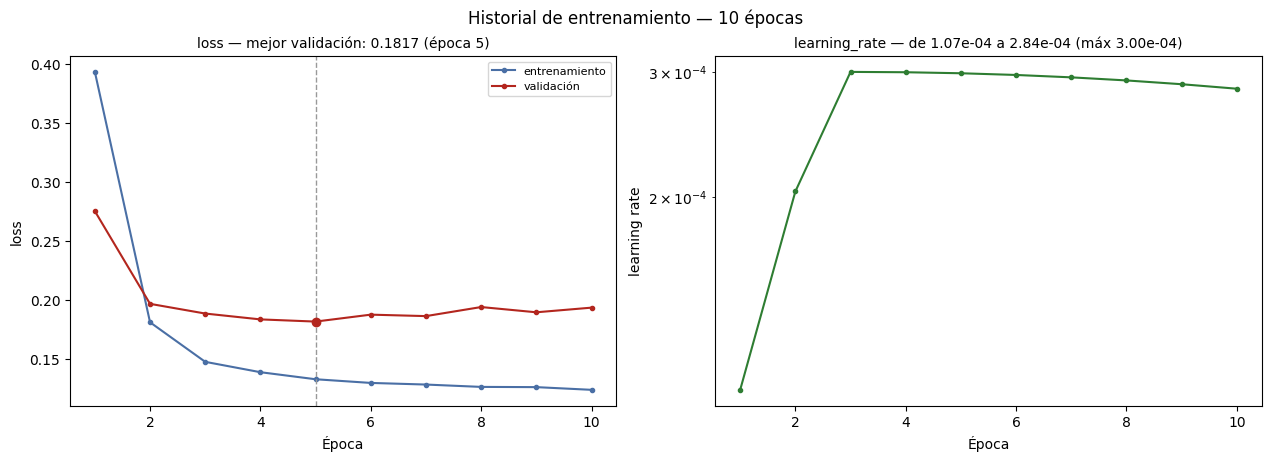

In [12]:
plot_history(history)

In [13]:
X_main = transform_pipeline.transform(main_df)
X_test = transform_pipeline.transform(anomaly_df)

X_main_window = sliding_window_view(X_main, window_shape=(WINDOW, X_main.shape[1])).squeeze()
X_test_window = sliding_window_view(X_test, window_shape=(WINDOW, X_test.shape[1])).squeeze()

123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step


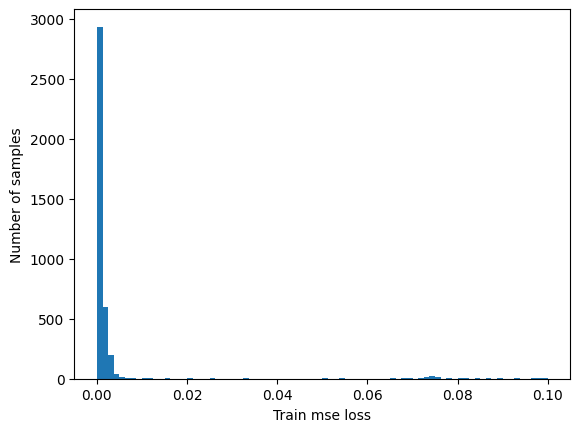

(np.float32(0.042301513),
 np.float32(0.07701836),
 np.float64(0.024371443898417056))

In [18]:
extractor.load_weights(RUTA_MODELO)
predictions_train = extractor.predict(X_main_window)
predictions_test = extractor.predict(X_test_window)

mae = np.mean(np.abs(predictions_train - predictions_test), axis=1)

plt.hist(mae, bins=80)
plt.xlabel("Train mse loss")
plt.ylabel("Number of samples")
plt.show()

threshold_std = np.mean(mae) + 3 * np.std(mae)

threshold_percentile = np.percentile(mae, 99)

q1, q3 = np.percentile(mae, [25, 75])
iqr = q3 - q1
threshold_iqr = q3 + (25 * iqr)

threshold_std, threshold_percentile, threshold_iqr

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


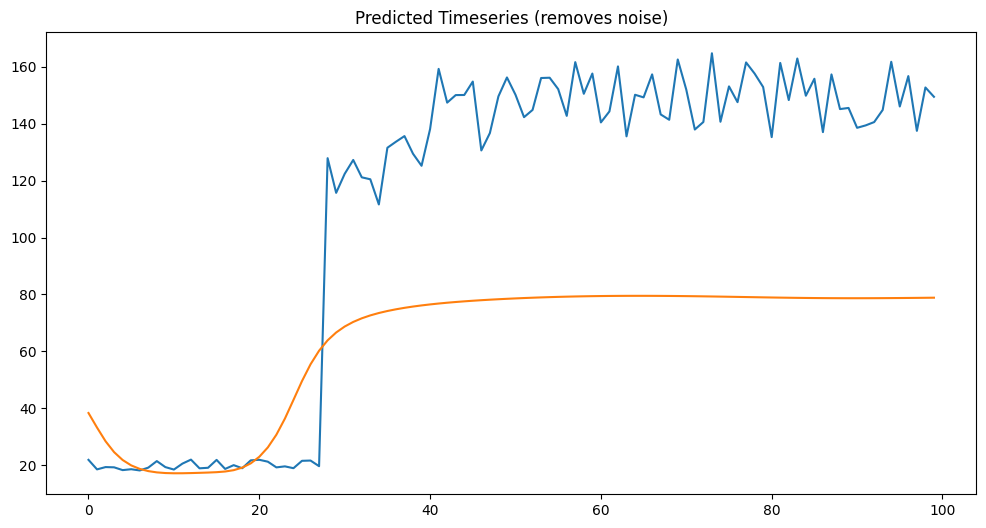

In [19]:
enc = transform_pipeline[-1]
scaler = enc.named_transformers_["remainder"]

k = 2960

inverse_window = scaler.inverse_transform(X_test_windows[k, :, 8:])

prediction = model.predict(X_test_windows[k][None, :])

inverse_preds = scaler.inverse_transform(prediction[0, :, 8:])

plt.figure(figsize=(12, 6))
plt.title("Predicted Timeseries (removes noise)")
plt.plot(inverse_window)
plt.plot(inverse_preds)
plt.show()

In [20]:
n = len(anomaly_df)

anomalous_data_indices1 = []
anomalous_data_indices2 = []
anomalous_data_indices3 = []

for k, data_idx in enumerate(range(WINDOW - 1, n - WINDOW + 1)):
    window = anomaly_df.iloc[data_idx - WINDOW + 1 : data_idx + 1]
    window_transformed = transform_pipeline.transform(window)
    window_embedding = extractor.predict(window_transformed[None, :], verbose="0")

    mae = np.mean(np.abs(predictions_train[k] - window_embedding), axis=1)

    if mae > threshold_std:
        anomalous_data_indices1.append(data_idx)

    if mae > threshold_percentile:
        anomalous_data_indices2.append(data_idx)

    if mae > threshold_iqr:
        anomalous_data_indices3.append(data_idx)

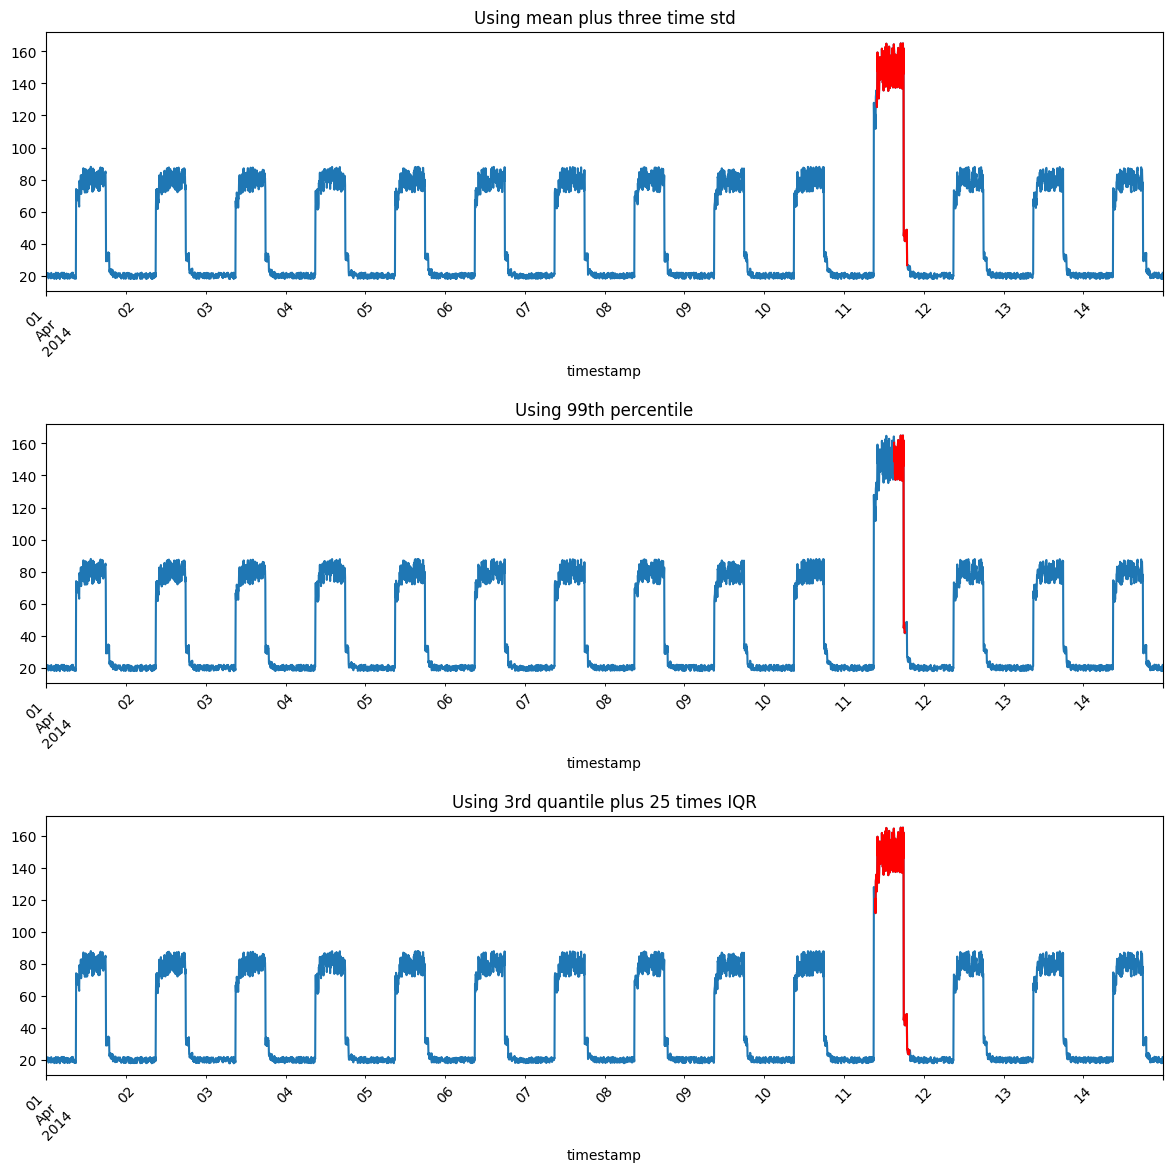

In [21]:
subset_anomalies1_df = anomaly_df.iloc[anomalous_data_indices1]
subset_anomalies2_df = anomaly_df.iloc[anomalous_data_indices2]
subset_anomalies3_df = anomaly_df.iloc[anomalous_data_indices3]

fig, ax = plt.subplots(3, 1, figsize=(12, 12))

ax[0].set_title("Using mean plus three time std")
anomaly_df.plot(
    x=anomaly_df.columns[0],
    rot=45,
    ax=ax[0],
    legend=False,
)
subset_anomalies1_df.plot(
    x=subset_anomalies1_df.columns[0],
    rot=45,
    ax=ax[0],
    color="red",
    legend=False,
)

ax[1].set_title("Using 99th percentile")
anomaly_df.plot(
    x=anomaly_df.columns[0],
    rot=45,
    ax=ax[1],
    legend=False,
)
subset_anomalies2_df.plot(
    x=subset_anomalies1_df.columns[0],
    rot=45,
    ax=ax[1],
    color="red",
    legend=False,
)

ax[2].set_title("Using 3rd quantile plus 25 times IQR")
anomaly_df.plot(
    x=anomaly_df.columns[0],
    rot=45,
    ax=ax[2],
    legend=False,
)
subset_anomalies3_df.plot(
    x=subset_anomalies1_df.columns[0],
    rot=45,
    ax=ax[2],
    color="red",
    legend=False,
)

plt.tight_layout(pad=1.7)
plt.show()